# Classification Part

In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv(f"E:\AirPulse AI\Files\data\processed_air_quality.csv")

In [15]:
df.head()

,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,temperature,humidity,wind_speed,hour,day,month,aqi
0,1.450487,0.519719,0.674688,-1.420657,0.562469,1.551509,-0.293566,0.205112,0.301189,1.180454,-0.316142,0.660868,-0.568606,0.939010,-1.784835,0.0,108
1,1.450487,0.519719,0.674688,-1.420657,-0.469550,-0.284383,0.294120,-0.820666,-0.302941,1.096537,-1.648118,1.187285,1.344121,1.083473,-1.784835,0.0,90
2,1.450487,0.519719,0.674688,-1.420657,0.106583,0.496056,-0.370482,1.426839,-1.655143,0.704924,1.085556,0.268974,1.592513,1.227936,-1.784835,0.0,84
3,1.450487,0.519719,0.674688,-1.420657,-0.564751,0.391971,2.277869,0.641006,-1.116764,-2.280128,0.171387,1.668330,1.339379,1.372399,-1.784835,0.0,158
4,1.450487,0.519719,0.674688,-1.420657,-1.092887,-0.149177,0.502292,0.359915,-0.163882,1.136497,-0.828489,0.996830,-0.462100,1.516862,-1.784835,0.0,97


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   country      18000 non-null  float64
 1   city         18000 non-null  float64
 2   latitude     18000 non-null  float64
 3   longitude    18000 non-null  float64
 4   pm25         18000 non-null  float64
 5   pm10         18000 non-null  float64
 6   no2          18000 non-null  float64
 7   so2          18000 non-null  float64
 8   o3           18000 non-null  float64
 9   co           18000 non-null  float64
 10  temperature  18000 non-null  float64
 11  humidity     18000 non-null  float64
 12  wind_speed   18000 non-null  float64
 13  hour         18000 non-null  float64
 14  day          18000 non-null  float64
 15  month        18000 non-null  float64
 16  aqi          18000 non-null  int64  
dtypes: float64(16), int64(1)
memory usage: 2.3 MB


In [17]:
def categorize_aqi(aqi):

    if aqi <= 50:
        return "Good"

    elif aqi <= 100:
        return "Moderate"

    elif aqi <= 150:
        return "Unhealthy"

    else:
        return "Hazardous"

In [18]:
df["aqi_category"] = df["aqi"].apply(categorize_aqi)

In [19]:
df["aqi_category"].value_counts()

aqi_category
Unhealthy    8874
Moderate     8108
Hazardous     847
Good          171
Name: count, dtype: int64

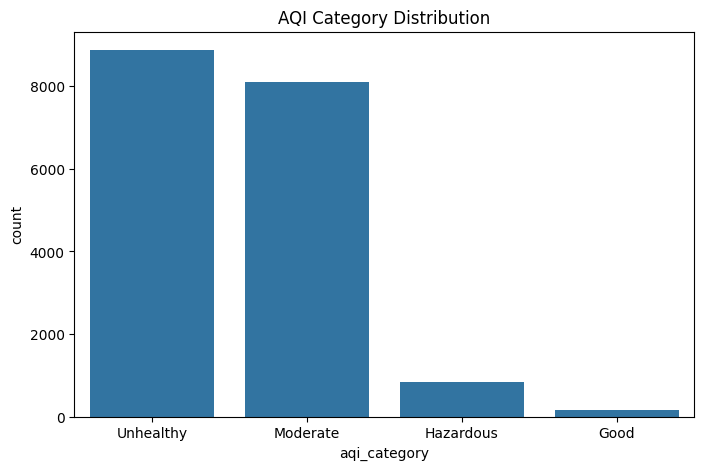

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="aqi_category",
    data=df
)

plt.title("AQI Category Distribution")

plt.show()

In [21]:
X = df.drop(["aqi", "aqi_category"], axis=1)

In [22]:
y = df["aqi_category"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'
